# Satisfactory Factory Build Plan

**What this shows:** For your current resource nodes, the LP optimizer found the
recipe mix that maximises AWESOME Sink points/min. This notebook converts those
fractional building counts into a concrete build spec:

- **Build plan table** — every active recipe: how many buildings to place and at
  what clock speed to set each one (always underclocked, never exceeds 100%)
- **Production graph** — a hierarchical diagram showing what feeds into what,
  flow rates on every connection, and orange/red highlighting on connections that
  need more than one physical belt line

## How to update when you claim new nodes

Edit `RESOURCE_SUPPLY` below and re-run top-to-bottom:

```python
'iron-ore': 5 * 480,   # was 5 veins → change to 7 * 480 after claiming 2 more
```

## How to unlock a new tier (e.g. bauxite after Phase 3)

Add the new resource to `RESOURCE_SUPPLY`:

```python
'bauxite':      4 * 480,   # Miner Mk.3 on pure node → 480/min each
'nitrogen-gas': 2 * 120,   # Resource Well Extractor equivalent
```

All tier 7–9 recipes are already in `data.json`. Adding the resource activates
the full aluminum/converter/quantum chain automatically.

## Switching objective: sink points → phase completion

To optimise for completing a specific Space Elevator phase, edit `solve.py`
and swap the objective line:

```python
# Current (sink points):
prob += pulp.lpSum(ITEMS[i].sink_points * net_expr(i) ...)

# Phase completion rate (e.g. Phase 4 parts):
PHASE4 = {'assembly-director-system', 'magnetic-field-generator',
           'thermal-propulsion-rocket', 'nuclear-pasta'}
prob += pulp.lpSum(net_expr(p) for p in PHASE4), "phase4_rate"
```


In [1]:
import os, sys, math
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

# Add graphviz dot binary to PATH (installed via Nix)
import subprocess
_gv = subprocess.run(
    ['nix-build', '<nixpkgs>', '-A', 'graphviz', '--no-out-link'],
    capture_output=True, text=True
).stdout.strip()
if _gv:
    os.environ['PATH'] = f"{_gv}/bin:{os.environ['PATH']}"

import pandas as pd
from IPython.display import display, HTML, SVG

from solve import solve, building_spec
from graph import build_graph, BELT_CAP
from satisfactory import ITEMS


## Resource Supply

Edit this cell when you claim new nodes, then re-run top-to-bottom.

In [2]:
# items/min from claimed extraction nodes
# Format: 'resource-key': n_veins * items_per_min_per_vein
RESOURCE_SUPPLY: dict[str, float] = {
    'iron-ore':     5 * 480,   # 2,400/min
    'copper-ore':   2 * 480,   #   960/min
    'coal':         3 * 480,   # 1,440/min
    'limestone':    2 * 480,   #   960/min
    'crude-oil':    2 * 300,   #   600/min
    'water':        99_999,    # effectively unlimited (Water Extractors)
    'caterium-ore': 2 * 480,   #   960/min
    # Add new resources as you unlock them, e.g.:
    # 'bauxite':      4 * 480,
    # 'nitrogen-gas': 2 * 120,
}


In [3]:
result = solve(RESOURCE_SUPPLY)
print(f"Status:          {result['status']}")
print(f"Sink points/min: {result['objective']:,.0f}")
print(f"Active recipes:  {len(result['active'])}")


Status:          Optimal
Sink points/min: 835,077
Active recipes:  36


## Build Plan

Every active recipe with its building count and clock speed.
**Clock %** is always ≤ 100% (underclocked) — set this in-game via the building's
clock speed dial. **Belt lines** in the Rate column shows ×N when a connection
exceeds 480/min (one physical belt line capacity).


In [4]:
rows = []
for r, rate in sorted(result['active'], key=lambda x: (x[0].building, x[0].name)):
    n, clk = building_spec(rate)
    rate_out = []
    for k, v in r.products.items():
        flow = v * rate
        belts = math.ceil(flow / BELT_CAP)
        item_name = ITEMS[k].name if k in ITEMS else k
        belt_str = f" (×{belts} belts)" if belts > 1 else ""
        rate_out.append(f"{item_name} {flow:.1f}/min{belt_str}")
    rows.append({
        'Recipe':   r.name,
        'Building': r.building,
        'Count':    n,
        'Clock %':  round(clk, 1),
        'Output':   ', '.join(rate_out),
    })

df = pd.DataFrame(rows)
display(
    df.style
    .hide(axis='index')
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
    .format({'Clock %': '{:.1f}%'})
)
print(f"\nTotal buildings to place: {df['Count'].sum()}")


Recipe,Building,Count,Clock %,Output
Diamonds,accelerator,1,11.6%,Diamonds 3.5/min
AI Limiter,assembler,5,90.6%,AI Limiter 22.6/min
Assembly Director System,assembler,2,79.4%,Assembly Director System 1.2/min
Automated Wiring,assembler,5,95.2%,Automated Wiring 11.9/min
Circuit Board,assembler,8,89.3%,Circuit Board 53.6/min
Electromagnetic Control Rod,assembler,6,84.4%,Electromagnetic Control Rod 20.3/min
Encased Industrial Beam,assembler,2,99.2%,Encased Industrial Beam 11.9/min
Magnetic Field Generator,assembler,17,94.7%,Magnetic Field Generator 16.1/min
Modular Frame,assembler,17,94.2%,Modular Frame 32.0/min
Reinforced Iron Plate,assembler,10,96.1%,Reinforced Iron Plate 48.0/min



Total buildings to place: 504


## Resource Utilization & Bottlenecks

**Shadow price**: how many extra sink points/min you'd gain by adding one more
unit/min of that resource. The highest shadow price is your real bottleneck —
claiming another node of that resource has the highest return.


In [5]:
util_rows = []
for res, supply in RESOURCE_SUPPLY.items():
    used  = result['used'].get(res, 0.0)
    shadow = result['shadow'].get(res, 0.0)
    util_rows.append({
        'Resource':   res,
        'Supply':     f"{supply:.0f}/min" if supply < 90_000 else '∞',
        'Used':       f"{used:.1f}/min",
        'Utilisation': f"{100*used/supply:.1f}%" if supply < 90_000 else 'N/A',
        'Shadow price (pts/unit/min)': round(shadow, 2),
    })

df_util = (
    pd.DataFrame(util_rows)
    .sort_values('Shadow price (pts/unit/min)', ascending=False)
    .reset_index(drop=True)
)
display(df_util.style.hide(axis='index'))


Resource,Supply,Used,Utilisation,Shadow price (pts/unit/min)
coal,1440/min,1440.0/min,100.0%,24.000000
limestone,960/min,960.0/min,100.0%,4.000000
iron-ore,2400/min,2400.0/min,100.0%,0.000000
copper-ore,960/min,960.0/min,100.0%,0.000000
crude-oil,600/min,600.0/min,100.0%,0.000000
water,∞,0.0/min,N/A,0.000000
caterium-ore,960/min,960.0/min,100.0%,0.000000


## Production Graph

Left → Right: raw ores enter on the left, AWESOME Sink items exit on the right.

| Visual element | Meaning |
|---|---|
| **Dark-red house nodes** (left) | Raw resource inputs |
| **Colored boxes** | Recipe nodes — color = building type, label = N× buildings @ clock% |
| **Dark ellipses** | Intermediate items that split or merge routes |
| **Green inverted-house nodes** (right) | Items being sunk (with points/min) |
| **Gray edges** | Single-belt flow (≤ 480/min) |
| **Orange edges** | 2–3 belt flows |
| **Bright-red edges** | 4+ belt flows |

Pass-through items appear as edge labels (not as separate nodes) to keep the graph compact.


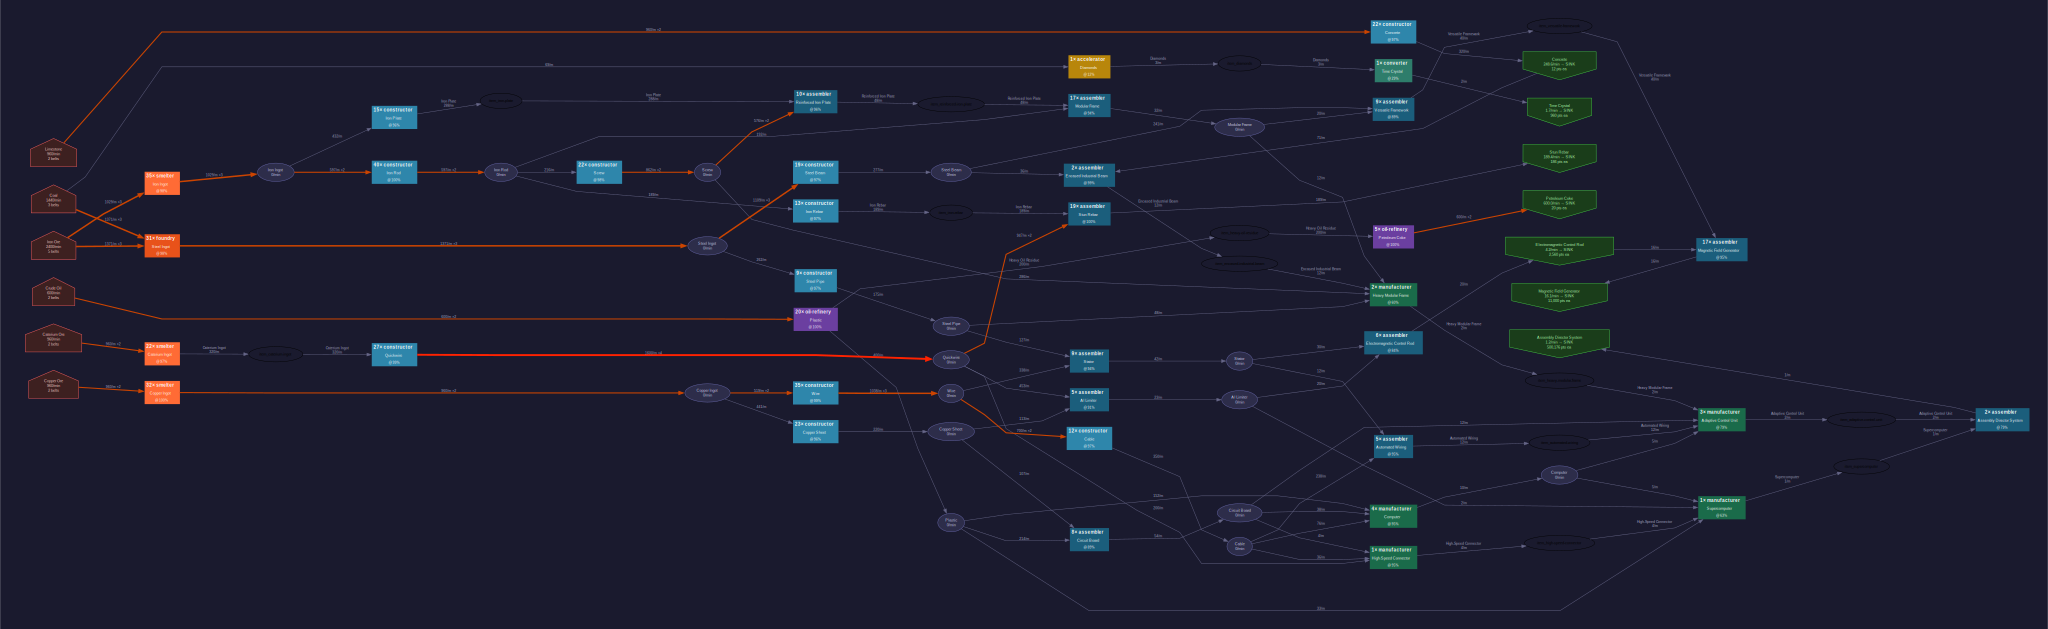

In [6]:
dot = build_graph(result['active'], result['net'], RESOURCE_SUPPLY)
svg_bytes = dot.pipe(format='svg')
display(SVG(svg_bytes))
